# Plan complet notebook : Livrable 2 – Traitement d’images

#  1. Introduction

Dans ce notebook, nous cherchons à améliorer la qualité d’images bruitées à l’aide d’un autoencodeur convolutif. Le but est de réaliser un prétraitement de données pour les rendre plus exploitables par des algorithmes de Machine Learning. Nous utiliserons un modèle d’autoencodeur entraîné à éliminer le bruit tout en conservant les détails visuels essentiels.

In [1]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from perlin_noise import PerlinNoise
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.preprocessing import image

# Machine learning / deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [3]:
print("TensorFlow:", tf.__version__)
print("Keras (lié à TF):", tf.keras.__version__)


TensorFlow: 2.20.0
Keras (lié à TF): 3.11.3


# 2. Chargement et exploration du dataset

Indique quel dataset on utilises et impémentation de certain hyper paramétre essentiele a l'entrainement

In [2]:
data_dir = 'C:/Users/REAL/PycharmProjects/Bloc_IA_FISE5/Datasett/train2014'

#data_dir = "Dataset_livrable2"
#data_dir = r"C:\Users\REAL\PycharmProjects\Bloc_IA_FISE5\Projet\TRUE_2_Livrable\Dataset_image_livrable2"

IMG_SIZE = (128, 128)

BATCH_SIZE = 32
EPOCHS = 10

SEED = 42

scale = 0.1

latent_dim = 10



# 2.1 Création du model

Dans cette partie nous assoctions notre data sett au hyperparamétre

il n'y a pas de label car ce n'est pas un modéle de classification

In [3]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode=None
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode=None
)

Found 82783 files.
Using 66227 files for training.
Found 82783 files.
Using 16556 files for validation.


 # 2.2 Data pre-processing

Uniformiser la taille des images
Les réseaux de neurones exigent que toutes les images aient la même dimension d’entrée (ex. 128×128×3).
→ Si nous avons des tailles différentes, le modèle ne pourra pas les traiter en batch.

Normaliser les valeurs de pixels
Les valeurs brutes des pixels vont de 0 à 255.
On les normalise entre 0 et 1 pour :

faciliter la convergence de l’entraînement,

stabiliser les calculs,

éviter des gradients trop grands.

Mélanger et batcher les données
Pour un apprentissage stable, il faut créer des lots (batches) d’images mélangées.
Cela permet d’optimiser plus efficacement les poids du réseau.

Ajouter du bruit aux images propres

In [4]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x: normalization_layer(x))
val_dataset = val_dataset.map(lambda x: normalization_layer(x))

In [5]:
# Optimisation (préchargement)
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Nous affichons quelque image de notre datasett

In [6]:
def display_images(dataset, n=10, title="Exemples d’images"):
    plt.figure(figsize=(10, 4))
    for images in dataset.take(1):  # Prend un batch d’images
        for i in range(n):
            ax = plt.subplot(2, 5, i + 1)
            plt.imshow(images[i].numpy())
            plt.axis("off")

    plt.suptitle(title)
    plt.show()

def display_noisy_images(dataset, n=5):
    for noisy_images, clean_images in dataset.take(1):
        plt.figure(figsize=(12, 4))
        for i in range(n):
            # Image propre
            ax = plt.subplot(2, n, i + 1)
            plt.imshow(clean_images[i].numpy())
            plt.title("Propre")
            plt.axis("off")

            # Image bruitée
            ax = plt.subplot(2, n, i + 1 + n)
            plt.imshow(noisy_images[i].numpy())
            plt.title("Bruitée")
            plt.axis("off")
        plt.show()


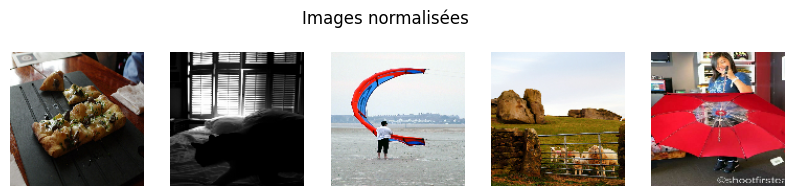

In [9]:
display_images(train_dataset, n=5, title="Images normalisées")



# 3. Ajout de bruit (simulation du bruit)

In [7]:
def add_noise(images, noise_factor=0.2):
    noisy = images + noise_factor * tf.random.normal(shape=tf.shape(images))
    noisy = tf.clip_by_value(noisy, 0., 1.)
    return noisy

train_noisy = train_dataset.map(lambda x: (add_noise(x), x))
val_noisy = val_dataset.map(lambda x: (add_noise(x), x))



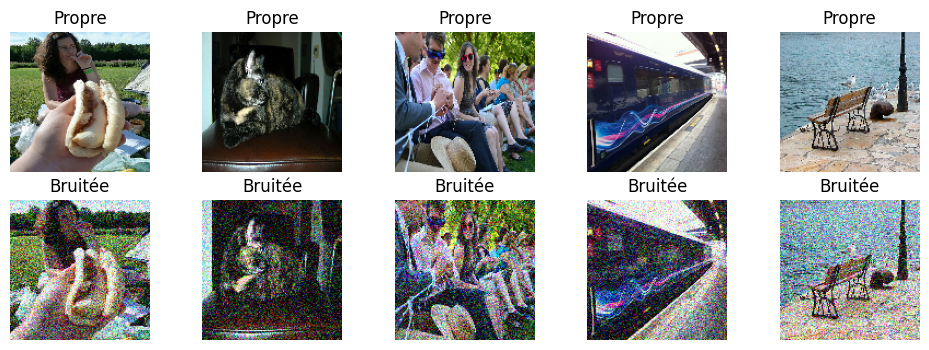

In [11]:
display_noisy_images(train_noisy, n=5)


### Résumé du pipeline de prétraitement








# 4. Construction de l’Autoencodeur Convolutionnel
Architecture type :

Un autoencodeur convolutionnel se compose de :

Encodeur : réduit la dimension via des convolutions + pooling.

Décodeur : reconstruit l’image via des convolutions transposées.

Exemple simple :

## 4.1 Autoencodeur Convolution

compresse l’image bruitée pour en extraire les caractéristiques essentielles (patterns, formes, textures).

les couche présente dans ce modéle :

#### Conv2D(n, (3,3))

Applique n filtres de convolution 3x3 sur l’image.
Chaque filtre détecte un motif local (contours, textures, couleurs…).
L’activation ReLU garde uniquement les valeurs positives → introduit de la non-linéarité.

#### MaxPooling2D
Réduit la taille des images de moitié (ex : 128×128 → 64×64).
Garde l’essentiel tout en éliminant les détails fins (comme du bruit !).

#### Flatten() transforme les cartes 2D en un vecteur 1D.

#### Dense(latent_dim) réduit à un espace latent

In [8]:
# The encoding process
input_img = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# ENCODEUR
x1 = layers.Conv2D(32, 3, activation='relu', padding='same')(input_img)
p1 = layers.MaxPooling2D((2, 2))(x1)

x2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
p2 = layers.MaxPooling2D((2, 2))(x2)

x3 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)

## 4.2 Decoder

C’est l’inverse : on reconstruit une image à partir du vecteur latent.

#### Dense + Reshape

On déplie le vecteur latent pour retrouver une forme 2D exploitable.
On part d’un petit cube de 16×16×16.

#### UpSampling2D
is just a simple scaling up of the image by using nearest neighbour or bilinear upsampling, so nothing smart. Advantage is it's cheap.

#### Conv2DTranspose
 is a convolution operation whose kernel is learnt (just like normal conv2d operation) while training your model. Using Conv2DTranspose will also upsample its input but the key difference is the model should learn what is the best upsampling for the job.

Ces couches ajoutent de plus en plus de détails visuels.
Plus de filtres → plus de richesse visuelle
Chaque étape reconstruit des textures et couleurs fines.

#### Activation

##### RELU

##### SIGMOID

valeurs normalisées entre 0 et 1 (pour une image propre).

In [9]:
# DÉCODEUR
u1 = layers.Conv2DTranspose(64, 3, strides=2, activation='relu', padding='same')(x3)
concat1 = layers.concatenate([u1, x2])  # Skip connection

u2 = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(concat1)
concat2 = layers.concatenate([u2, x1])

output = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(concat2)

encoder = keras.Model(input_img, output, name="encoder")

## Autre architecture d'AE

Lors de nos entrainement nous avons tester pluseiur type d'architecture:

le probléme avec celle et que la fonction de cout a tendance a stagner pour Mean Absolute Error et Mean Squared Error

le résulat de débruitage est donc affécter par cela est n'est pas très performant

In [6]:
# The encoding process
input_img = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# --- ENCODEUR ---

input_img = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.Flatten()(x)

z = layers.Dense(latent_dim, name="latent_vector")(x)

encoder = keras.Model(input_img, z, name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 10)             │     1,310,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,403,978 (5.36 MB)

 Trainable params: 1,403,978 (5.36 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# --- DÉCODEUR ---
latent_inputs = keras.Input(shape=(latent_dim,))

# On re-projette dans une forme 2D

x = layers.Dense(32 * 32 * 64, activation='relu')(latent_inputs)
x = layers.Reshape((32, 32, 64))(x)

x = layers.Conv2DTranspose(128, (3, 3), activation='relu', padding='same', strides=2)(x)  # 64x64
x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same', strides=2)(x)   # 128x128
decoded_output = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)
decoder = keras.Model(latent_inputs, decoded_output, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 65536)          │       720,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 64, 64, 128)    │        73,856 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 128, 128, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 870,275 (3.32 MB)

 Trainable params: 870,275 (3.32 MB)

 Non-trainable params: 0 (0.00 B)

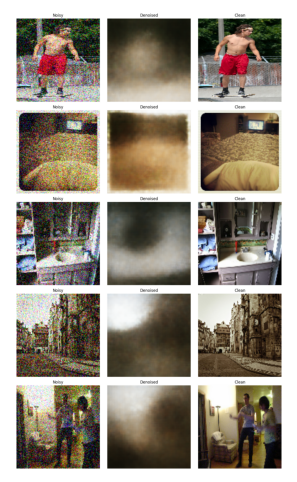

In [15]:
image_rater = 'C:/Users/REAL/PycharmProjects/Bloc_IA_FISE5/Projet/TRUE_2_Livrable/progress_images_test/epoch_004.png'

# Charger l'image
img = plt.imread(image_rater)

# Afficher
plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.axis('off')
plt.show()

## AE

un autoencodeur de débruitage, deux éléments clés pilotent l’apprentissage :

    -1.l’optimiseur

    -2.la fonction de coût


Le but du débruitage est de transformer une image bruitée (entrée) en une image propre (sortie).
Le modèle apprend cesi via une fonction de cout, c'est pout cela qu'on a essyer plusieur modéle avec plusieur fonction de cout pour améliorais le résultat finale

La fonction de coût mesure à quel point la sortie du modèle est différente de l’image originale.

In [10]:
# Declare the model
autoencoder_input = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
encoded_img = encoder(autoencoder_input)
decoded_img = encoder(encoded_img)

autoencoder = keras.Model(autoencoder_input, decoded_img, name="autoencoder")
autoencoder.compile(optimizer='adamW',
                    loss='mae',
                    metrics=[tf.keras.metrics.MeanSquaredError()]
)
autoencoder.summary()


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ (None, 128, 128,  │    205,667 │ input_layer_1[0]… │
│ (Functional)        │ 3)                │            │ encoder[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 205,667 (803.39 KB)

 Trainable params: 205,667 (803.39 KB)

 Non-trainable params: 0 (0.00 B)

### Callback

In [15]:
class DenoisingProgressCallback(tf.keras.callbacks.Callback):
    def __init__(self, dataset, output_dir='progress_images', num_images=5):
        super().__init__()
        self.output_dir = output_dir
        os.makedirs(output_dir, exist_ok=True)

        # On récupère un petit batch du dataset (noisy, clean)
        sample_noisy, sample_clean = next(iter(dataset))
        self.sample_noisy = sample_noisy[:num_images].numpy()
        self.sample_clean = sample_clean[:num_images].numpy()

    def on_epoch_end(self, epoch, logs=None):
        predictions = self.model.predict(self.sample_noisy)
        num_images = len(self.sample_noisy)

        plt.figure(figsize=(12, 4 * num_images))
        for i in range(num_images):
            plt.subplot(num_images, 3, 3 * i + 1)
            plt.imshow(self.sample_noisy[i])
            plt.title("Noisy")
            plt.axis("off")

            plt.subplot(num_images, 3, 3 * i + 2)
            plt.imshow(predictions[i])
            plt.title("Denoised")
            plt.axis("off")

            plt.subplot(num_images, 3, 3 * i + 3)
            plt.imshow(self.sample_clean[i])
            plt.title("Clean")
            plt.axis("off")

        save_path = os.path.join(self.output_dir, f"epoch_{epoch+1:03d}.png")
        plt.tight_layout()
        plt.savefig(save_path)
        plt.close()
        print(f"Images sauvegardées : {save_path}")


In [28]:
import tensorflow as tf
import matplotlib.pyplot as plt

class ImageAccuracyCallback(tf.keras.callbacks.Callback):
    def __init__(self, noisy_data, clean_data, interval=100):
        super().__init__()
        self.noisy_data = noisy_data
        self.clean_data = clean_data
        self.interval = interval
        self.batch_count = 0
        self.ssim_scores = []
        self.psnr_scores = []

    def on_batch_end(self, batch, logs=None):
        self.batch_count += 1

        if self.batch_count % self.interval == 0:
            # Récupère un petit batch pour l’évaluation
            noisy_batch, clean_batch = next(iter(zip(self.noisy_data, self.clean_data)))

            # Prédiction sur les images bruitées
            preds = self.model.predict(noisy_batch, verbose=0)

            # Calcul des métriques visuelles
            ssim_value = tf.reduce_mean(tf.image.ssim(clean_batch, preds, max_val=1.0))
            psnr_value = tf.reduce_mean(tf.image.psnr(clean_batch, preds, max_val=1.0))

            self.ssim_scores.append(ssim_value.numpy())
            self.psnr_scores.append(psnr_value.numpy())

            print(f"\n🖼️ Batch {self.batch_count}: SSIM={ssim_value:.4f}, PSNR={psnr_value:.2f}")

    def on_train_end(self, logs=None):
        # Tracer la courbe des scores SSIM
        plt.figure(figsize=(10, 5))
        plt.plot(self.ssim_scores, label='SSIM')
        plt.plot(self.psnr_scores, label='PSNR')
        plt.xlabel(f'Batch (×{self.interval})')
        plt.ylabel('Score')
        plt.title('Évolution SSIM / PSNR pendant l’entraînement')
        plt.legend()
        plt.show()


# 5. Entraînement du modèle

In [29]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('AE_6H_0.0041_MSE.keras', save_best_only=True, monitor='val_loss'),
    DenoisingProgressCallback(train_noisy, output_dir='progress_images', num_images=5),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
#    ImageAccuracyCallback(noisy_data=val_noisy, clean_data=train_dataset, interval=10)
]


In [ ]:
history = autoencoder.fit(
    train_noisy,
    validation_data=val_noisy,
    epochs=3,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/3
  28/2070 ━━━━━━━━━━━━━━━━━━━━ 39:31 1s/step - loss: 0.0958 - mean_squared_error: 0.0176

In [13]:
history = autoencoder.fit(
    train_noisy,
    validation_data=val_noisy,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/steps/step - los
Images sauvegardées : progress_images\epoch_001.png
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 2146s 1s/step - loss: 0.0616 - mean_squared_error: 0.0084 - val_loss: 0.0512 - val_mean_squared_error: 0.0057
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/steptep - los
Images sauvegardées : progress_images\epoch_002.png
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 2262s 1s/step - loss: 0.0496 - mean_squared_error: 0.0053 - val_loss: 0.0478 - val_mean_squared_error: 0.0050
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/steptep - los
Images sauvegardées : progress_images\epoch_003.png
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 2249s 1s/step - loss: 0.0470 - mean_squared_error: 0.0048 - val_loss: 0.0465 - val_mean_squared_error: 0.0047
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/steps/step - loss
Images sauvegardées : progress_images\epoch_004.png
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 2113s 1s/step - loss: 0.0459 - mean_squared_error: 0.0046 - val_loss: 0.0454 - val_mean_squared

# 5.1 AUTRE MODEL HYPERPARAMETRE



Nous aurons pus faire tout c'est changement et choisire le modéle le plus perfomrant :

Optimiseur → adam, adamW, rmsprop, ou sgd.
Exemple : tester RMSprop(learning_rate=0.0005) pour voir l’effet sur la stabilité.

Taux d’apprentissage (learning_rate) → contrôle la vitesse d’ajustement des poids.
Exemple : 1e-2 vs 1e-4.

Fonction de perte (loss) → mae, mse, ou binary_crossentropy.

Batch size → nombre d’images traitées avant chaque mise à jour des poids.

Nombre d’époques → nombre de passages complets sur le jeu de données.


In [ ]:
# Declare the model
autoencoder_input = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
encoded_img = encoder(autoencoder_input)
decoded_img = encoder(encoded_img)

autoencoder = keras.Model(autoencoder_input, decoded_img, name="autoencoder")
autoencoder.compile(optimizer='adamW',
                    loss='mae',
                    metrics=[tf.keras.metrics.MeanSquaredError()]
)

history = autoencoder.fit(
    train_noisy,
    validation_data=val_noisy,
    epochs=3,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks,
    verbose=1,
)

# 6. Évaluation & Visualisation des résultats

Afficher les résultats :

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step


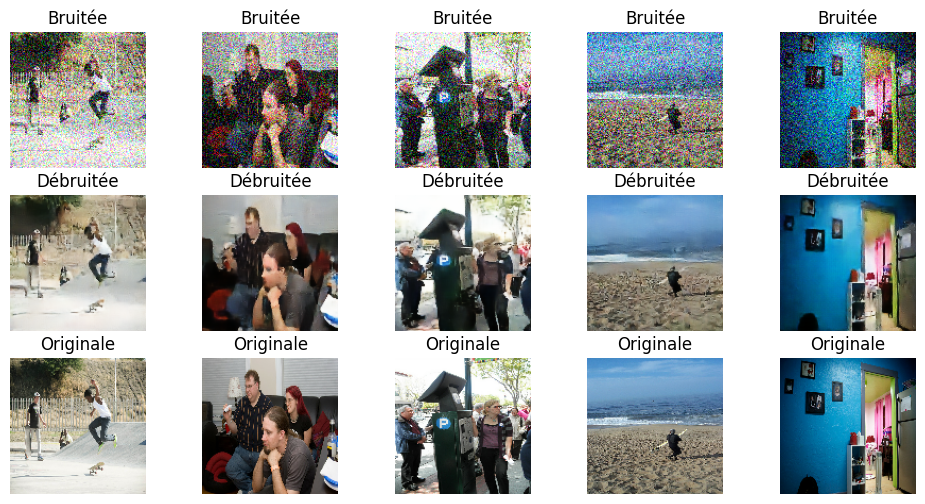

In [24]:
for noisy_imgs, clean_imgs in val_noisy.take(1):
    denoised_imgs = autoencoder.predict(noisy_imgs)

    plt.figure(figsize=(12, 6))
    for i in range(5):
        ax = plt.subplot(3,5,i+1)
        plt.imshow(noisy_imgs[i])
        plt.title("Bruitée")
        plt.axis("off")

        ax = plt.subplot(3,5,i+6)
        plt.imshow(denoised_imgs[i])
        plt.title("Débruitée")
        plt.axis("off")

        ax = plt.subplot(3,5,i+11)
        plt.imshow(clean_imgs[i])
        plt.title("Originale")
        plt.axis("off")
    plt.show()

In [25]:
def evaluate_batch(clean, pred):
    # clean, pred : tensors shape (B,H,W,C) values in [0,1]
    psnr = tf.image.psnr(clean, pred, max_val=1.0)
    ssim = tf.image.ssim(clean, pred, max_val=1.0)
    return tf.reduce_mean(psnr).numpy(), tf.reduce_mean(ssim).numpy()

# Exemple d'utilisation sur validation
for noisy, clean in val_noisy.take(1):
    pred = autoencoder.predict(noisy)
    print("PSNR:", evaluate_batch(clean, pred)[0])
    print("SSIM:", evaluate_batch(clean, pred)[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
PSNR: 24.43369
SSIM: 0.73302996


# 7. Étude de cas (interprétation)

## 7.1 courbe

Text(0.5, 1.0, 'Courbe de convergence (Loss / Val_loss)')

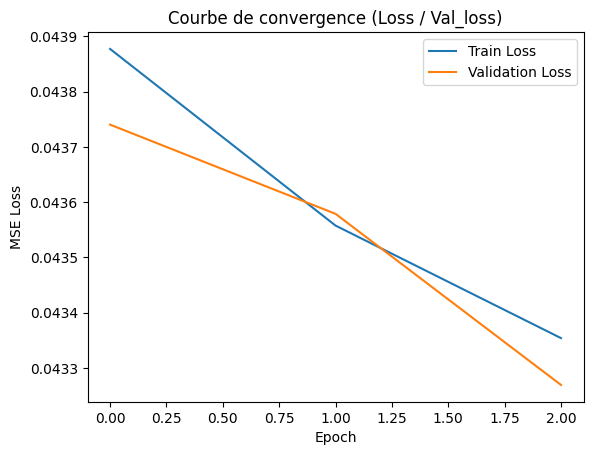

In [32]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Courbe de convergence (Loss / Val_loss)')


## 7.2 Application d'autre image

Modèle chargé: AE_6H_0.0041_MSE.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step


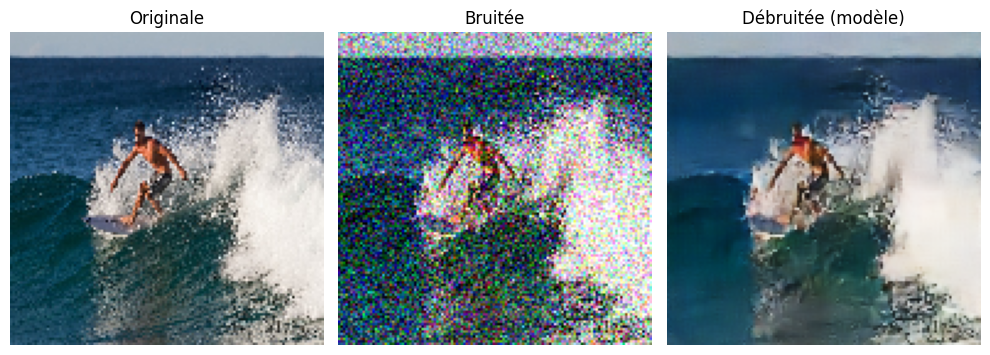

In [27]:
# === 1. Charger le modèle entraîné ===
model_path = "AE_6H_0.0041_MSE.keras"
autoencoder = tf.keras.models.load_model(model_path, compile=False)
print("Modèle chargé:", model_path)

# === 2. Charger une image hors dataset ===
test_image_path = "Dataset_image_livrable2/noisy_001.jpg"
IMG_SIZE = (128, 128)

# Charger et redimensionner
img = image.load_img(test_image_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# === 3. Ajouter du bruit ===
noise_factor = 0.2
noisy_img = img_array + noise_factor * np.random.normal(size=img_array.shape)
noisy_img = np.clip(noisy_img, 0., 1.)

# === 4. Passer l'image dans le modèle ===
denoised_img = autoencoder.predict(noisy_img)

# === 5. Afficher les résultats ===
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_array[0])
plt.title("Originale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(noisy_img[0])
plt.title("Bruitée")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(denoised_img[0])
plt.title("Débruitée (modèle)")
plt.axis("off")

plt.tight_layout()
plt.show()


# 8. Conclusion

Le modèle d’autoencodeur conçu dans ce projet a démontré sa capacité à réduire efficacement le bruit présent dans les images, en apprenant à reconstruire une version plus propre à partir d’entrées dégradées. Les courbes de perte (loss) montrent une convergence stable entre les ensembles d’entraînement et de validation, confirmant une bonne généralisation du modèle sur des données non vues.

Cependant, les résultats obtenus restent brouillons : certaines images conservent un flou résiduel ou une perte de détails fins, signe que l’architecture actuelle atteint ses limites de représentation.

Plusieurs axes d’amélioration peuvent être envisagés :

-Approfondir l’architecture du réseau plus de couches de convolution et davantage de filtres par couche afin de capter des caractéristiques plus complexes.

-Optimiser le système de bruitage pour qu’il reflète mieux les conditions réelles, rendant ainsi le modèle plus robuste et adaptable à divers types de perturbations qui peut arrivée dans la vraie vie .

-Explorer d’autres types de bruits gaussien, impulsionnel, de compression, afin d’évaluer la polyvalence du modèle et d'améliorer aca génraliter.

-Enfin, envisager l’utilisation de réseaux convolutionnels plus avancés comme U-Net ou DnCNN, souvent plus performants pour les tâches de débruitage.


En somme, ce projet constitue la premiére etape de mise en place d’un pipeline de débruitage d’images.
